/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,979 (11.64 KB)

 Trainable params: 2,979 (11.64 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 6s 104ms/step - accuracy: 0.5833 - loss: 1.0541 - val_accuracy: 0.7083 - val_loss: 1.0450
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6146 - loss: 1.0016 - val_accuracy: 0.7500 - val_loss: 0.9853
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.7708 - loss: 0.8937 - val_accuracy: 0.7500 - val_loss: 0.9099
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.8125 - loss: 0.8320 - val_accuracy: 0.7500 - val_loss: 0.8392
Epoch 5/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.8021 - loss: 0.7179 - val_accuracy: 0.7500 - val_loss: 0.7693
Epoch 6/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.8125 - loss: 0.6110 - val_accuracy: 0.7500 - val_loss: 0.6913
Epoch 7/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.8229 - loss: 0.5416 - val_accuracy: 0.7917 - val_loss: 0.6181
Epoch 8/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.8438 - loss: 0.4817 - val_accuracy: 0.8333 - 

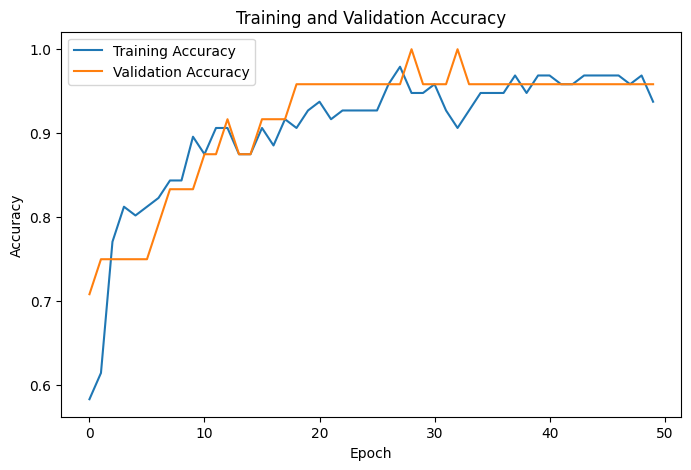

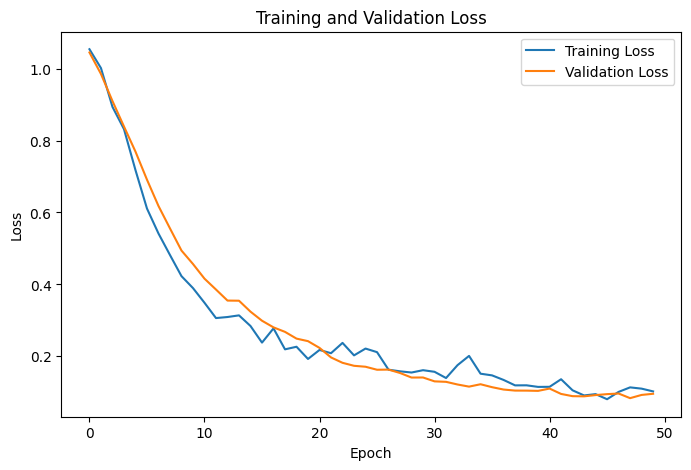

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical


# --------------------------------------------------
# Load Real Dataset
# --------------------------------------------------

iris = load_iris()

X = iris.data
y = iris.target

# Convert target to categorical format
y = to_categorical(y, num_classes=3)


# --------------------------------------------------
# Split Dataset
# --------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# --------------------------------------------------
# Standardize Data
# --------------------------------------------------

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# --------------------------------------------------
# Design Deep Neural Network
# --------------------------------------------------

model = Sequential([
    Dense(64, activation="relu", input_shape=(4,)),
    Dropout(0.2),

    Dense(32, activation="relu"),
    Dropout(0.2),

    Dense(16, activation="relu"),

    Dense(3, activation="softmax")
])


# --------------------------------------------------
# Compile Model
# --------------------------------------------------

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)


# Display architecture
model.summary()


# --------------------------------------------------
# Train Model
# --------------------------------------------------

history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=10,
    validation_split=0.2,
    verbose=1
)


# --------------------------------------------------
# Evaluate Model
# --------------------------------------------------

loss, accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("\n======================================")
print("DEEP NEURAL NETWORK RESULTS")
print("======================================")

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)


# --------------------------------------------------
# Plot Accuracy
# --------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")

plt.legend()
plt.show()


# --------------------------------------------------
# Plot Loss
# --------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")

plt.legend()
plt.show()